In [206]:
import pandas as pd

objects = pd.read_csv("objects_cleaned (2).csv")

objects.head()

,entity_id,name,entity_type,category_code,status,founded_at,funding_total_usd,funding_rounds
0,1,Wetpaint,Company,web,operating,2005-10-17,39750000.0,3
1,10000,MYWEBBO,Company,network_hosting,operating,2008-07-26,0.0,0
2,10001,THE Movie Streamer,Company,games_video,operating,2008-07-26,0.0,0
3,10002,Synergie Media,Company,advertising,operating,2007-06-27,0.0,0
4,10003,Green Basti Ecosystems,Company,cleantech,operating,2008-08-20,0.0,0


In [207]:
ipos = pd.read_csv("ipos_clean.csv")

ipos.head()

,id,object_id,valuation_amount,raised_amount,public_at,stock_symbol,source_description,created_at,updated_at,ipo_year,ipo_month
0,1,c:1654,0.000000e+00,0.0,1980-12-19,NASDAQ:AAPL,NaN,2008-02-09 05:17:45,2012-04-12 04:02:59,1980,12
1,2,c:1242,0.000000e+00,0.0,1986-03-13,NASDAQ:MSFT,NaN,2008-02-09 05:25:18,2010-12-11 12:39:46,1986,3
2,3,c:342,0.000000e+00,0.0,1969-06-09,NYSE:DIS,NaN,2008-02-09 05:40:32,2010-12-23 08:58:16,1969,6
3,4,c:59,0.000000e+00,0.0,2004-08-25,NASDAQ:GOOG,NaN,2008-02-10 22:51:24,2011-08-01 20:47:08,2004,8
4,5,c:317,1.000000e+11,0.0,1997-05-01,NASDAQ:AMZN,NaN,2008-02-10 23:28:09,2011-08-01 21:11:22,1997,5


In [208]:
acquisitions = pd.read_csv("acquisitions_clean.csv")

acquisitions.head()

,id,acquisition_id,acquiring_object_id,acquired_object_id,term_code,price_amount,price_currency_code,acquired_at,source_url,source_description,created_at,updated_at,acquired_year
0,1,1,c:11,c:10,Unknown,20000000,USD,2007-05-30,http://venturebeat.com/2007/05/30/fox-interact...,Fox Interactive confirms purchase of Photobuck...,2007-05-31 22:19:54,2008-05-21 19:23:44,2007.0
1,2,7,c:59,c:72,cash,60000000,USD,2007-07-01,http://www.techcrunch.com/2007/07/02/deal-is-c...,Deal is Confirmed: Google Acquired GrandCentral,2007-07-03 08:14:50,2011-05-06 21:51:05,2007.0
2,3,8,c:24,c:132,cash,280000000,USD,2007-05-01,http://www.techcrunch.com/2007/05/30/cbs-acqui...,CBS Acquires Europeâs Last.fm for $280 million,2007-07-12 04:19:24,2008-05-19 04:48:50,2007.0
3,4,9,c:59,c:155,cash,100000000,USD,2007-06-01,http://techcrunch.com/2007/05/23/100-million-p...,$100 Million Payday For Feedburner  This Deal...,2007-07-13 09:52:59,2012-06-05 03:22:17,2007.0
4,5,10,c:212,c:215,cash,25000000,USD,2007-07-01,http://blog.seattlepi.nwsource.com/venture/arc...,seatlepi.com,2007-07-20 05:29:07,2008-02-25 00:23:47,2007.0


In [214]:
ipos['object_id'] = (
    ipos['object_id']
    .astype(str)
    .str.replace('c:', '', regex=False)
    .astype(int)
)

In [216]:
acquisitions['acquired_object_id'] = pd.to_numeric(
    acquisitions['acquired_object_id']
        .astype(str)
        .str.replace('c:', '', regex=False),
    errors='coerce'
)

In [211]:
ipos_df = ipos.merge(objects, left_on='object_id', right_on='entity_id', how='left')
ipos_df['Exit Type'] = 'IPO'

In [177]:
acq_df = acquisitions.merge(objects, left_on='acquired_object_id', right_on='entity_id', how='left')
acq_df['Exit Type'] = 'Acquisition'

In [178]:
data = pd.concat([ipos_df, acq_df], ignore_index=True)
data.head()

,id,object_id,valuation_amount,raised_amount,public_at,stock_symbol,source_description,created_at,updated_at,ipo_year,...,Exit Type,acquisition_id,acquiring_object_id,acquired_object_id,term_code,price_amount,price_currency_code,acquired_at,source_url,acquired_year
0,1,1654,0.0,0.0,1980-12-19,NASDAQ:AAPL,NaN,2008-02-09 05:17:45,2012-04-12 04:02:59,1980.0,...,IPO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1654,0.0,0.0,1980-12-19,NASDAQ:AAPL,NaN,2008-02-09 05:17:45,2012-04-12 04:02:59,1980.0,...,IPO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1242,0.0,0.0,1986-03-13,NASDAQ:MSFT,NaN,2008-02-09 05:25:18,2010-12-11 12:39:46,1986.0,...,IPO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1242,0.0,0.0,1986-03-13,NASDAQ:MSFT,NaN,2008-02-09 05:25:18,2010-12-11 12:39:46,1986.0,...,IPO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,342,0.0,0.0,1969-06-09,NYSE:DIS,NaN,2008-02-09 05:40:32,2010-12-23 08:58:16,1969.0,...,IPO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [179]:
ml_data = data[[
    'category_code',
    'funding_total_usd',
    'funding_rounds',
    'founded_at',
    'Exit Type'
]].copy()

In [234]:
import numpy as np

ml_data['funding_total_usd'] = ml_data['funding_total_usd'].fillna(0)
ml_data['funding_rounds'] = ml_data['funding_rounds'].fillna(0)

ml_data['founded_at'] = pd.to_datetime(ml_data['founded_at'], errors='coerce')
ml_data['age'] = 2026 - ml_data['founded_at'].dt.year
ml_data['age'] = ml_data['age'].fillna(ml_data['age'].median())
ml_data['log_funding'] = np.log1p(ml_data['funding_total_usd'])
ml_data['avg_round_size'] = ml_data['funding_total_usd'] / (ml_data['funding_rounds'] + 1)
ml_data['funding_per_year'] = ml_data['funding_total_usd'] / (ml_data['age'] + 1)
ml_data['rounds_per_year'] = ml_data['funding_rounds'] / (ml_data['age'] + 1)
top_cats = ml_data['category_code'].value_counts().nlargest(20).index
ml_data['category_code'] = ml_data['category_code'].where(
    ml_data['category_code'].isin(top_cats),
    'Other'
)

ml_data = ml_data.dropna(subset=['category_code', 'Exit Type'])

In [235]:
ml_data.head()

,category_code,funding_total_usd,funding_rounds,founded_at,Exit Type,age,log_funding,avg_round_size,funding_per_year,rounds_per_year,funding_x_rounds,log_age
0,hardware,0.0,0.0,1976-04-01,IPO,50.0,0.0,0.0,0.0,0.0,0.0,3.931826
1,Unknown,0.0,0.0,2001-01-01,IPO,25.0,0.0,0.0,0.0,0.0,0.0,3.258097
2,software,0.0,0.0,1974-04-04,IPO,52.0,0.0,0.0,0.0,0.0,0.0,3.970292
3,Unknown,0.0,0.0,2007-11-01,IPO,19.0,0.0,0.0,0.0,0.0,0.0,2.995732
4,games_video,0.0,0.0,1923-10-16,IPO,103.0,0.0,0.0,0.0,0.0,0.0,4.644391


In [236]:
from sklearn.utils import resample

ipo = ml_data[ml_data['Exit Type'] == 'IPO']
acq = ml_data[ml_data['Exit Type'] == 'Acquisition']

ipo_upsampled = resample(
    ipo,
    replace=True,
    n_samples=len(acq),
    random_state=42
)

balanced = pd.concat([acq, ipo_upsampled])

In [237]:
X = pd.get_dummies(balanced[[
    'category_code',
    'log_funding',
    'funding_rounds',
    'age',
    'avg_round_size',
    'funding_per_year',
    'rounds_per_year'
]])
y = balanced['Exit Type']

In [238]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7508369201339072
              precision    recall  f1-score   support

           0       0.71      0.85      0.77      2091
           1       0.81      0.65      0.72      2091

    accuracy                           0.75      4182
   macro avg       0.76      0.75      0.75      4182
weighted avg       0.76      0.75      0.75      4182



<Figure size 1000x600 with 0 Axes>

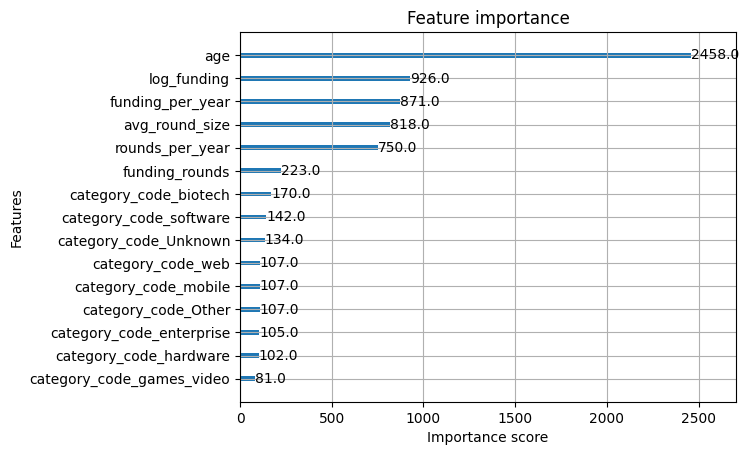

In [239]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=15)
plt.show()